# Gaze Detection with MPIIGaze Dataset
### Deep Learning Pipeline: CNN-based Gaze Estimation + Live Camera Inference


In [ ]:

import subprocess, sys

packages = [
    'torch', 'torchvision', 'torchaudio',
    'numpy', 'scipy', 'opencv-python',
    'matplotlib', 'tqdm', 'scikit-learn',
    'Pillow'
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All packages installed.')

✅ All packages installed.


In [ ]:
import os
import glob
import numpy as np
import scipy.io as sio
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import torchvision.models as models

from sklearn.metrics import mean_absolute_error
from PIL import Image

# Device setup
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
else:
    print('No GPU detected. Training will be slower on CPU.')

🖥️  Using device: cpu
   ⚠️  No GPU detected. Training will be slower on CPU.


In [ ]:

DATA_ROOT    = r'MPIIGaze/MPIIGaze/Data/Normalized'
PARTICIPANTS = [f'p{i:02d}' for i in range(3)]   

IMG_SIZE     = 60
BATCH_SIZE   = 64
NUM_EPOCHS   = 3        
LR           = 1e-3
WEIGHT_DECAY = 1e-4
VAL_SPLIT    = 0.10     
TEST_SPLIT   = 0.05     
SEED         = 42


ANG_EVAL_EVERY = 2

MODEL_SAVE_PATH = 'gaze_model.pth'

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f'Participants : {PARTICIPANTS}')
print(f'Epochs       : {NUM_EPOCHS}')
print(f'Batch size   : {BATCH_SIZE}')
print(f'Val split    : {VAL_SPLIT}')
print(f'Angular eval : every {ANG_EVAL_EVERY} epochs')

Participants : ['p00', 'p01', 'p02']
Epochs       : 3
Batch size   : 64
Val split    : 0.1
Angular eval : every 2 epochs


In [ ]:

def load_mpiigaze_data(data_root, participants):
    images = []
    labels = []
    skipped = 0

    for pid in tqdm(participants, desc='Loading participants'):
        p_dir = os.path.join(data_root, pid)
        if not os.path.isdir(p_dir):
            print(f'Missing: {p_dir}')
            continue

        mat_files = sorted(glob.glob(os.path.join(p_dir, '*.mat')))

        for mat_path in mat_files:
            try:
                mat  = sio.loadmat(mat_path, squeeze_me=True)
                data = mat['data']          

                for eye_side in ('left', 'right'):
                    eye_struct = data[eye_side].item()   
                    imgs  = eye_struct['image'].item()   
                    gaze  = eye_struct['gaze'].item()[:, :2]    
                    if imgs.ndim == 2:
                        imgs = imgs[np.newaxis]
                        gaze = gaze[np.newaxis]

                    images.append(imgs.astype(np.uint8))
                    labels.append(gaze.astype(np.float32))

            except Exception as e:
                skipped += 1

    if not images:
        raise RuntimeError(f'No data loaded from {data_root}.')

    images = np.concatenate(images, axis=0)
    labels = np.concatenate(labels, axis=0)

    print(f'\nLoaded {len(images):,} samples  |  Skipped: {skipped}')
    print(f'   Image shape : {images.shape}')
    print(f'   Label shape : {labels.shape}')
    print(f'   Pitch range : [{np.degrees(labels[:,0].min()):.1f}°, {np.degrees(labels[:,0].max()):.1f}°]')
    print(f'   Yaw range   : [{np.degrees(labels[:,1].min()):.1f}°, {np.degrees(labels[:,1].max()):.1f}°]')

    return images, labels


images_raw, labels_raw = load_mpiigaze_data(DATA_ROOT, PARTICIPANTS)

Loading participants: 100%|██████████| 3/3 [00:12<00:00,  4.00s/it]



✅ Loaded 164,242 samples  |  Skipped: 2
   Image shape : (164242, 36, 60)
   Label shape : (164242, 2)
   Pitch range : [-40.3°, 15.4°]
   Yaw range   : [-3.6°, 20.9°]


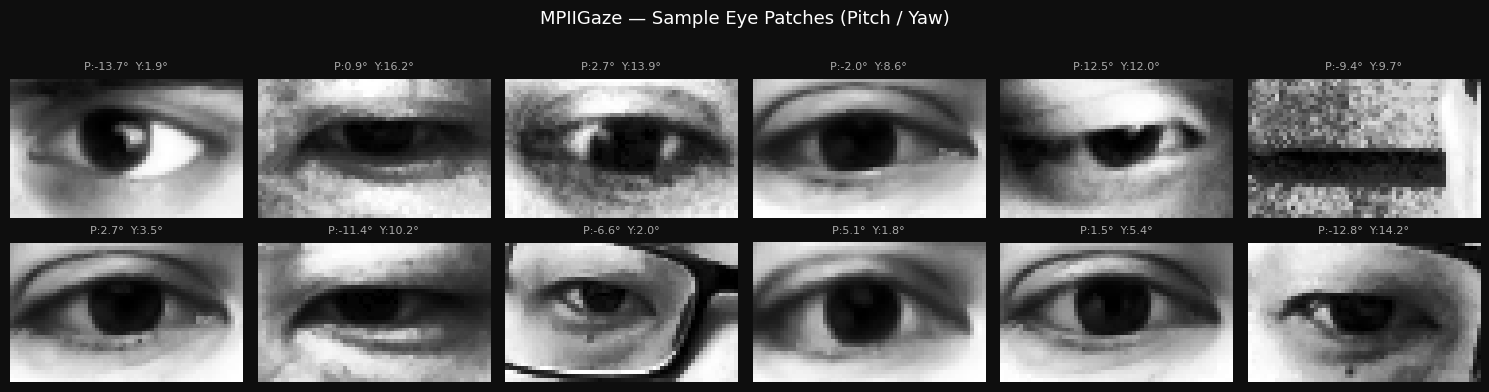

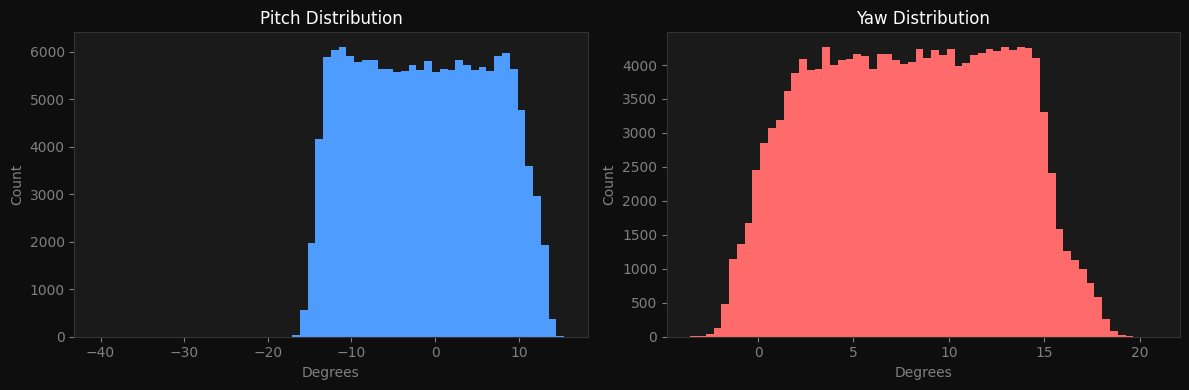

In [ ]:
def visualize_samples(images, labels, n=12):
    """Display a grid of eye patches with their gaze labels."""
    idx = np.random.choice(len(images), n, replace=False)
    cols = 6
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2))
    fig.patch.set_facecolor('#0e0e0e')

    for ax_idx, i in enumerate(idx):
        r, c = divmod(ax_idx, cols)
        ax = axes[r][c] if rows > 1 else axes[c]
        img = images[i]
        if img.ndim == 2:
            ax.imshow(img, cmap='gray')
        else:
            ax.imshow(img)
        pitch_deg = np.degrees(labels[i, 0])
        yaw_deg   = np.degrees(labels[i, 1])
        ax.set_title(f'P:{pitch_deg:.1f}°  Y:{yaw_deg:.1f}°',
                     fontsize=8, color='#aaaaaa')
        ax.axis('off')

    for ax_idx in range(n, rows * cols):
        r, c = divmod(ax_idx, cols)
        ax = axes[r][c] if rows > 1 else axes[c]
        ax.axis('off')

    plt.suptitle('MPIIGaze — Sample Eye Patches (Pitch / Yaw)',
                 color='white', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


def visualize_label_distribution(labels):
    """Plot pitch & yaw distributions."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.patch.set_facecolor('#0e0e0e')
    for ax in (ax1, ax2):
        ax.set_facecolor('#1a1a1a')
        ax.tick_params(colors='gray')
        for spine in ax.spines.values():
            spine.set_edgecolor('#333')

    ax1.hist(np.degrees(labels[:, 0]), bins=60, color='#4f9cff', edgecolor='none')
    ax1.set_title('Pitch Distribution', color='white')
    ax1.set_xlabel('Degrees', color='gray')
    ax1.set_ylabel('Count', color='gray')

    ax2.hist(np.degrees(labels[:, 1]), bins=60, color='#ff6b6b', edgecolor='none')
    ax2.set_title('Yaw Distribution', color='white')
    ax2.set_xlabel('Degrees', color='gray')
    ax2.set_ylabel('Count', color='gray')

    plt.tight_layout()
    plt.show()


visualize_samples(images_raw, labels_raw)
visualize_label_distribution(labels_raw)

In [ ]:
class FastGazeDataset(Dataset):
    def __init__(self, images, labels, img_size=60):
        self.img_size = img_size
        self.labels   = torch.tensor(labels, dtype=torch.float32)

        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        self.mean = torch.tensor(mean).view(3, 1, 1)
        self.std  = torch.tensor(std).view(3, 1, 1)

        # Resize all images ONCE and store as uint8 — ~3.2 GB instead of 12.9 GB
        print(f'Resizing {len(images):,} images to {img_size}x{img_size} (uint8)...')
        self.images = np.zeros((len(images), img_size, img_size), dtype=np.uint8)
        for i, img in enumerate(tqdm(images, desc='Resizing', leave=False)):
            if img.ndim == 3:
                img = img[0] if img.shape[0] == 1 else cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            self.images[i] = cv2.resize(img, (img_size, img_size))
        print(f'   Stored as uint8: {self.images.nbytes / 1e9:.2f} GB')

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]                           
        x = torch.tensor(
            np.stack([img, img, img], axis=0), dtype=torch.float32
        ) / 255.0
        x = (x - self.mean) / self.std            
        return x, self.labels[idx]

n_total = len(images_raw)
n_val   = int(n_total * VAL_SPLIT)
n_test  = int(n_total * TEST_SPLIT)
n_train = n_total - n_val - n_test

idx    = np.random.RandomState(SEED).permutation(n_total)
tr_idx = idx[:n_train]
vl_idx = idx[n_train:n_train+n_val]
te_idx = idx[n_train+n_val:]

train_ds_fast = FastGazeDataset(images_raw[tr_idx], labels_raw[tr_idx], IMG_SIZE)
val_ds_fast   = FastGazeDataset(images_raw[vl_idx], labels_raw[vl_idx], IMG_SIZE)
test_ds_fast  = FastGazeDataset(images_raw[te_idx], labels_raw[te_idx], IMG_SIZE)

train_loader = DataLoader(train_ds_fast, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds_fast,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds_fast,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)

print(f'\nTrain: {n_train:,}  |  Val: {n_val:,}  |  Test: {n_test:,}')

Resizing 139,606 images to 60x60 (uint8)...


   Stored as uint8: 0.50 GB
Resizing 16,424 images to 60x60 (uint8)...


   Stored as uint8: 0.06 GB
Resizing 8,212 images to 60x60 (uint8)...


   Stored as uint8: 0.03 GB

Train: 139,606  |  Val: 16,424  |  Test: 8,212


In [ ]:
class GazeEstimator(nn.Module):
    
    def __init__(self, pretrained=True, dropout=0.4):
        super().__init__()

        backbone = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT if pretrained else None
        )
        self.features = nn.Sequential(*list(backbone.children())[:-1])

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),

            nn.Linear(128, 2),   
        )

    def forward(self, x):
        feat = self.features(x)  
        gaze = self.regressor(feat)
        return gaze


model = GazeEstimator(pretrained=True).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model built: GazeEstimator (ResNet-18)')
print(f'   Total params    : {total_params:,}')
print(f'   Trainable params: {trainable_params:,}')
print(f'   Device          : {DEVICE}')

✅ Model built: GazeEstimator (ResNet-18)
   Total params    : 11,341,762
   Trainable params: 11,341,762
   Device          : cpu


## Block 7 — Loss, Optimizer & Scheduler

In [ ]:

def angular_error(pred, target):

    def to_vec(angles):
        pitch = angles[:, 0]
        yaw   = angles[:, 1]
        x = -torch.cos(pitch) * torch.sin(yaw)
        y = -torch.sin(pitch)
        z = -torch.cos(pitch) * torch.cos(yaw)
        return torch.stack([x, y, z], dim=1)

    pred_v   = to_vec(pred)
    target_v = to_vec(target)
    cos_sim  = (pred_v * target_v).sum(dim=1).clamp(-1 + 1e-7, 1 - 1e-7)
    angles   = torch.acos(cos_sim)  
    return torch.mean(angles) * (180.0 / np.pi) 


criterion = nn.MSELoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)

print('Optimizer  : AdamW')
print('Scheduler  : CosineAnnealingLR')
print('Loss       : MSELoss (+ Angular Error metric)')
print(f'LR          : {LR}')
print(f'Weight Decay: {WEIGHT_DECAY}')

✅ Optimizer  : AdamW
✅ Scheduler  : CosineAnnealingLR
✅ Loss       : MSELoss (+ Angular Error metric)
   LR          : 0.001
   Weight Decay: 0.0001


In [ ]:
import time
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, criterion, epoch, num_epochs):
    model.train()
    running_loss = 0.0

    pbar = tqdm(loader, desc=f'Epoch {epoch}/{num_epochs} [Train]',
                leave=False, ncols=80)

    for imgs, labels in pbar:
        imgs   = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        preds = model(imgs)
        loss  = criterion(preds, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    return running_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, epoch, num_epochs, compute_angular=False):
    model.eval()
    running_loss = 0.0
    running_ang  = 0.0

    pbar = tqdm(loader, desc=f'Epoch {epoch}/{num_epochs} [Val]  ',
                leave=False, ncols=80)

    for imgs, labels in pbar:
        imgs   = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        preds = model(imgs)
        loss  = criterion(preds, labels)
        running_loss += loss.item() * imgs.size(0)

        if compute_angular:
            running_ang += angular_error(preds, labels).item() * imgs.size(0)

        pbar.set_postfix({'val_loss': f'{loss.item():.4f}'})

    n        = len(loader.dataset)
    avg_loss = running_loss / n
    avg_ang  = (running_ang / n) if compute_angular else None
    return avg_loss, avg_ang


history = {'train_loss': [], 'val_loss': [], 'val_ang': []}

best_val_loss = float('inf')
best_epoch    = 0

print(f'Starting training for {NUM_EPOCHS} epochs')
print(f'Batch size   : {BATCH_SIZE}')
print(f'Angular eval : every {ANG_EVAL_EVERY} epochs\n')

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    tr_loss = train_one_epoch(model, train_loader, optimizer, criterion,
                              epoch, NUM_EPOCHS)

    do_ang  = (epoch % ANG_EVAL_EVERY == 0) or (epoch == NUM_EPOCHS)
    vl_loss, vl_ang = evaluate(model, val_loader, criterion,
                               epoch, NUM_EPOCHS,
                               compute_angular=do_ang)

    scheduler.step()
    elapsed = time.time() - t0
    eta     = elapsed * (NUM_EPOCHS - epoch)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['val_ang'].append(vl_ang)

    marker = ''
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_epoch    = epoch
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        marker = ' <--best'

    cur_lr  = optimizer.param_groups[0]['lr']
    ang_str = f'{vl_ang:.2f} deg' if vl_ang is not None else '---'

    print(f'Epoch {epoch:>3}/{NUM_EPOCHS} | '
          f'loss {tr_loss:.4f}/{vl_loss:.4f} | '
          f'ang {ang_str} | '
          f'{elapsed:.0f}s | ETA {eta/60:.1f}min | '
          f'lr {cur_lr:.1e}{marker}')

print(f'\nBest epoch : {best_epoch}')
print(f'Val loss   : {best_val_loss:.5f}')
print(f'Saved to   : {MODEL_SAVE_PATH}')

Starting training for 3 epochs
Batch size   : 64
Angular eval : every 2 epochs



Epoch   1/3 | loss 0.0050/0.0016 | ang --- | 3536s | ETA 117.9min | lr 7.5e-04 <--best


Epoch   2/3 | loss 0.0015/0.0010 | ang 2.01 deg | 2196s | ETA 36.6min | lr 2.5e-04 <--best


Epoch   3/3 | loss 0.0011/0.0009 | ang 1.95 deg | 2811s | ETA 0.0min | lr 1.0e-06 <--best

Best epoch : 3
Val loss   : 0.00086
Saved to   : gaze_model.pth


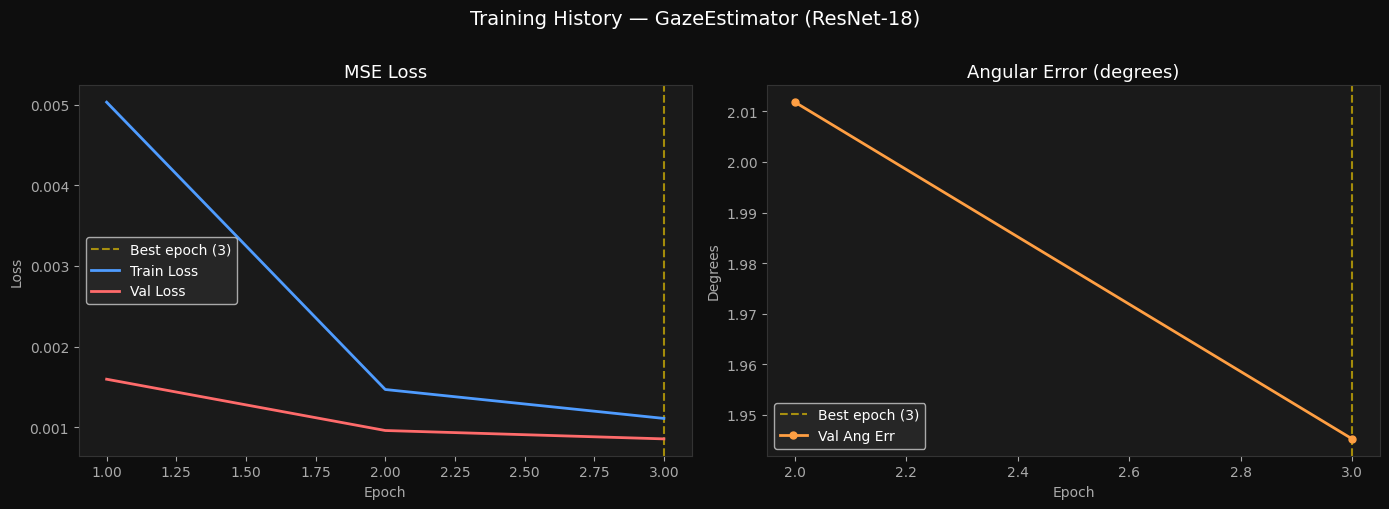

In [ ]:
def plot_training_history(history, best_epoch):
    epochs = range(1, len(history['train_loss']) + 1)

    has_ang = any(v is not None for v in history['val_ang'])

    if has_ang:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        axes = [ax1, ax2]
    else:
        fig, ax1 = plt.subplots(1, 1, figsize=(7, 5))
        axes = [ax1]

    fig.patch.set_facecolor('#0e0e0e')

    for ax in axes:
        ax.set_facecolor('#1a1a1a')
        ax.tick_params(colors='#aaa')
        for spine in ax.spines.values():
            spine.set_edgecolor('#333')
        ax.axvline(best_epoch, color='#ffd700', linestyle='--',
                   alpha=0.6, label=f'Best epoch ({best_epoch})')

    ax1.plot(epochs, history['train_loss'], '#4f9cff', lw=2, label='Train Loss')
    ax1.plot(epochs, history['val_loss'],   '#ff6b6b', lw=2, label='Val Loss')
    ax1.set_title('MSE Loss', color='white', fontsize=13)
    ax1.set_xlabel('Epoch', color='#aaa')
    ax1.set_ylabel('Loss',  color='#aaa')
    ax1.legend(facecolor='#2a2a2a', labelcolor='white', framealpha=0.8)

    if has_ang:
        ang_epochs = [e for e, v in zip(epochs, history['val_ang']) if v is not None]
        ang_vals   = [v for v in history['val_ang'] if v is not None]
        ax2.plot(ang_epochs, ang_vals, '#ff9f43', lw=2, marker='o',
                 markersize=5, label='Val Ang Err')
        ax2.set_title('Angular Error (degrees)', color='white', fontsize=13)
        ax2.set_xlabel('Epoch', color='#aaa')
        ax2.set_ylabel('Degrees', color='#aaa')
        ax2.legend(facecolor='#2a2a2a', labelcolor='white', framealpha=0.8)

    plt.suptitle('Training History — GazeEstimator (ResNet-18)',
                 color='white', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


plot_training_history(history, best_epoch)

Evaluating on test set: 100%|██████████| 129/129 [00:37<00:00,  3.47it/s]


          TEST SET RESULTS
  Pitch MAE        : 1.349°
  Yaw MAE          : 1.144°
  Mean Angular Err : 1.938°


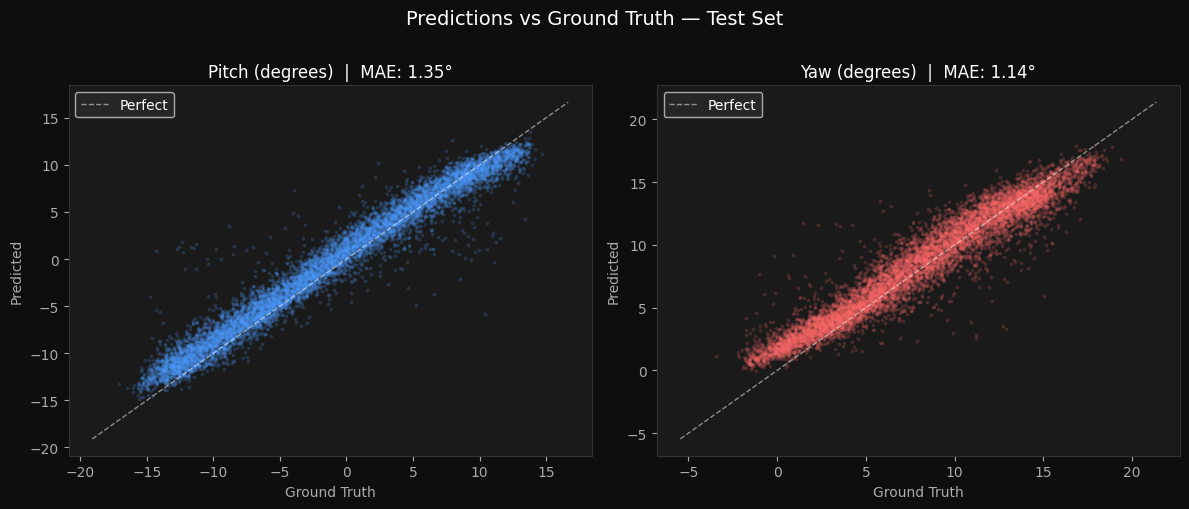

In [ ]:

model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=DEVICE))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Evaluating on test set'):
        imgs   = imgs.to(DEVICE)
        preds  = model(imgs).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.numpy())

all_preds  = np.concatenate(all_preds,  axis=0)
all_labels = np.concatenate(all_labels, axis=0)

pitch_mae = mean_absolute_error(all_labels[:, 0], all_preds[:, 0])
yaw_mae   = mean_absolute_error(all_labels[:, 1], all_preds[:, 1])

p_t = torch.tensor(all_preds)
l_t = torch.tensor(all_labels)
ang_err = angular_error(p_t, l_t).item()

print('=' * 45)
print('          TEST SET RESULTS')
print('=' * 45)
print(f'  Pitch MAE        : {np.degrees(pitch_mae):.3f}°')
print(f'  Yaw MAE          : {np.degrees(yaw_mae):.3f}°')
print(f'  Mean Angular Err : {ang_err:.3f}°')
print('=' * 45)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#0e0e0e')

for ax, idx, title, color in [
    (ax1, 0, 'Pitch (degrees)', '#4f9cff'),
    (ax2, 1, 'Yaw (degrees)',   '#ff6b6b')
]:
    ax.set_facecolor('#1a1a1a')
    ax.tick_params(colors='#aaa')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333')

    true_deg = np.degrees(all_labels[:, idx])
    pred_deg = np.degrees(all_preds[:, idx])

    ax.scatter(true_deg, pred_deg, alpha=0.15, s=3, c=color)
    lim = [min(true_deg.min(), pred_deg.min()) - 2,
           max(true_deg.max(), pred_deg.max()) + 2]
    ax.plot(lim, lim, 'white', lw=1, linestyle='--', alpha=0.5, label='Perfect')
    ax.set_xlabel('Ground Truth', color='#aaa')
    ax.set_ylabel('Predicted',    color='#aaa')
    ax.set_title(f'{title}  |  MAE: {np.degrees(mean_absolute_error(all_labels[:,idx],all_preds[:,idx])):.2f}°',
                 color='white')
    ax.legend(facecolor='#2a2a2a', labelcolor='white')

plt.suptitle('Predictions vs Ground Truth — Test Set',
             color='white', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
def draw_gaze_arrow(frame, center, pitch, yaw,
                    length=100, color=(0, 255, 100), thickness=3):
  
    dx = -length * np.cos(pitch) * np.sin(yaw)
    dy = -length * np.sin(pitch)

    x0, y0 = int(center[0]), int(center[1])
    x1, y1 = int(center[0] + dx), int(center[1] + dy)

    cv2.arrowedLine(frame, (x0, y0), (x1, y1),
                    color, thickness, tipLength=0.35)
    cv2.circle(frame, (x0, y0), 5, color, -1)
    return frame


def preprocess_eye_for_model(eye_roi, img_size=IMG_SIZE):

    tf = T.Compose([
        T.Resize((img_size, img_size)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std =[0.229, 0.224, 0.225]),
    ])
    if eye_roi.ndim == 2:
        pil = Image.fromarray(eye_roi).convert('RGB')
    else:
        pil = Image.fromarray(cv2.cvtColor(eye_roi, cv2.COLOR_BGR2RGB))
    return tf(pil).unsqueeze(0).to(DEVICE)


print('Gaze arrow utilities defined.')

✅ Gaze arrow utilities defined.


In [ ]:

HAAR_BASE = cv2.data.haarcascades

face_cascade = cv2.CascadeClassifier(
    os.path.join(HAAR_BASE, 'haarcascade_frontalface_default.xml')
)
eye_cascade  = cv2.CascadeClassifier(
    os.path.join(HAAR_BASE, 'haarcascade_eye.xml')
)

if face_cascade.empty() or eye_cascade.empty():
    raise RuntimeError(
        'Haar cascade files not found. '
        'Make sure OpenCV is installed correctly.'
    )

print('Face & Eye Haar Cascades loaded.')
print(f'Face cascade : haarcascade_frontalface_default.xml')
print(f'Eye  cascade : haarcascade_eye.xml')

✅ Face & Eye Haar Cascades loaded.
   Face cascade : haarcascade_frontalface_default.xml
   Eye  cascade : haarcascade_eye.xml


In [ ]:
import time

model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=DEVICE))
model.eval()

cap = cv2.VideoCapture(0)  
if not cap.isOpened():
    raise IOError('Cannot open webcam. Check camera index.')

cap.set(cv2.CAP_PROP_FRAME_WIDTH,  1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT,  720)
cap.set(cv2.CAP_PROP_FPS, 30)


COL_FACE  = (255, 200,  50)
COL_EYE   = ( 50, 220, 255)
COL_GAZE  = ( 50, 255, 100)
COL_TEXT  = (255, 255, 255)
COL_BG    = (  0,   0,   0)

FONT      = cv2.FONT_HERSHEY_DUPLEX
MIN_EYE_W = 40   
prev_time = time.time()
screenshot_count = 0

print('Starting live gaze detection. Press Q to quit, S to screenshot.')

while True:
    ret, frame = cap.read()
    if not ret:
        print('Failed to grab frame. Exiting.')
        break
    cur_time = time.time()
    fps      = 1.0 / max(cur_time - prev_time, 1e-6)
    prev_time = cur_time

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = cv2.equalizeHist(gray)  
    faces = face_cascade.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=5,
        minSize=(80, 80)
    )

    gaze_data = []

    for (fx, fy, fw, fh) in faces:
        cv2.rectangle(frame, (fx, fy), (fx + fw, fy + fh),
                      COL_FACE, 2)

        roi_gray  = gray [fy:fy+fh, fx:fx+fw]
        roi_color = frame[fy:fy+fh, fx:fx+fw]

        eyes = eye_cascade.detectMultiScale(
            roi_gray, scaleFactor=1.05, minNeighbors=4,
            minSize=(MIN_EYE_W, MIN_EYE_W)
        )

        for (ex, ey, ew, eh) in eyes:

            cv2.rectangle(roi_color,
                          (ex, ey), (ex + ew, ey + eh),
                          COL_EYE, 2)

            eye_roi = roi_gray[ey:ey+eh, ex:ex+ew]
            if eye_roi.size == 0:
                continue

            with torch.no_grad():
                inp   = preprocess_eye_for_model(eye_roi)
                pred  = model(inp).cpu().numpy()[0]
                pitch, yaw = float(pred[0]), float(pred[1])

            center_x = fx + ex + ew // 2
            center_y = fy + ey + eh // 2

            draw_gaze_arrow(frame, (center_x, center_y),
                            pitch, yaw, length=80,
                            color=COL_GAZE, thickness=2)

            label_str = f'P:{np.degrees(pitch):+.1f}° Y:{np.degrees(yaw):+.1f}°'
            cv2.putText(frame, label_str,
                        (fx + ex, fy + ey - 6),
                        FONT, 0.42, COL_EYE, 1, cv2.LINE_AA)

            gaze_data.append((pitch, yaw))

    hud_lines = [
        f'FPS: {fps:.1f}',
        f'Faces: {len(faces)}',
        f'Eyes : {len(gaze_data)}',
    ]
    if gaze_data:
        avg_pitch = np.degrees(np.mean([g[0] for g in gaze_data]))
        avg_yaw   = np.degrees(np.mean([g[1] for g in gaze_data]))
        hud_lines.append(f'Avg  P:{avg_pitch:+.1f}° Y:{avg_yaw:+.1f}°')

    for i, line in enumerate(hud_lines):
        cv2.putText(frame, line, (12, 28 + i * 26),
                    FONT, 0.65, COL_TEXT, 1, cv2.LINE_AA)

    cv2.putText(frame, 'Q:quit  S:screenshot',
                (12, frame.shape[0] - 12),
                FONT, 0.5, (150, 150, 150), 1, cv2.LINE_AA)

    cv2.imshow('Gaze Detection — MPIIGaze Model', frame)

    key = cv2.waitKey(1) & 0xFF
    if key == ord('q') or key == 27:
        break
    if key == ord('s'):
        fname = f'screenshot_{screenshot_count:03d}.png'
        cv2.imwrite(fname, frame)
        print(f'Screenshot saved: {fname}')
        screenshot_count += 1


cap.release()
cv2.destroyAllWindows()
print('Camera released. Demo ended.')

📷 Starting live gaze detection. Press Q to quit, S to screenshot.
✅ Camera released. Demo ended.


In [ ]:


IMAGE_PATH = 'test_face.jpg'   

if not os.path.exists(IMAGE_PATH):
    print(f'Image not found: {IMAGE_PATH}. Skipping Block 14.')
else:
    model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=DEVICE))
    model.eval()

    img_bgr  = cv2.imread(IMAGE_PATH)
    gray     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray     = cv2.equalizeHist(gray)
    output   = img_bgr.copy()

    faces = face_cascade.detectMultiScale(gray, 1.1, 5, minSize=(60,60))

    for (fx, fy, fw, fh) in faces:
        cv2.rectangle(output, (fx, fy), (fx+fw, fy+fh), (255,200,50), 2)
        roi_g = gray [fy:fy+fh, fx:fx+fw]
        roi_c = output[fy:fy+fh, fx:fx+fw]

        eyes = eye_cascade.detectMultiScale(roi_g, 1.05, 4, minSize=(40,40))
        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_c, (ex,ey), (ex+ew, ey+eh), (50,220,255), 2)
            eye_roi = roi_g[ey:ey+eh, ex:ex+ew]
            if eye_roi.size == 0: continue
            with torch.no_grad():
                inp = preprocess_eye_for_model(eye_roi)
                pred = model(inp).cpu().numpy()[0]
            pitch, yaw = float(pred[0]), float(pred[1])
            cx = fx + ex + ew//2
            cy = fy + ey + eh//2
            draw_gaze_arrow(output, (cx,cy), pitch, yaw)
            cv2.putText(output,
                        f'P:{np.degrees(pitch):+.1f}° Y:{np.degrees(yaw):+.1f}°',
                        (fx+ex, fy+ey-6), cv2.FONT_HERSHEY_DUPLEX,
                        0.45, (50,220,255), 1, cv2.LINE_AA)

    output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 7))
    plt.imshow(output_rgb)
    plt.axis('off')
    plt.title('Static Image Gaze Detection', fontsize=14)
    plt.tight_layout()
    plt.show()

⚠️  Image not found: test_face.jpg. Skipping Block 14.


In [ ]:
torch.save({
    'epoch'          : best_epoch,
    'model_state'    : model.state_dict(),
    'optimizer_state': optimizer.state_dict(),
    'best_val_loss'  : best_val_loss,       
    'history'        : history,
    'config'         : {
        'img_size'  : IMG_SIZE,
        'batch_size': BATCH_SIZE,
        'lr'        : LR,
        'epochs'    : NUM_EPOCHS,
    }
}, 'gaze_model_full.pth')

print('Saved to: gaze_model_full.pth')
print(f'   Best epoch     : {best_epoch}')
print(f'   Best val loss  : {best_val_loss:.5f}')
print("""
To reload:
    ckpt  = torch.load('gaze_model_full.pth')
    model = GazeEstimator(pretrained=False)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
""")

Saved to: gaze_model_full.pth
   Best epoch     : 3
   Best val loss  : 0.00086

To reload:
    ckpt  = torch.load('gaze_model_full.pth')
    model = GazeEstimator(pretrained=False)
    model.load_state_dict(ckpt['model_state'])
    model.eval()

